### Carregamento das bibliotecas

In [112]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Carregamento dos dados

In [113]:
df_produtos = pd.read_csv("../data/processed/produtos_processed.csv")
df_custos_importacao = pd.read_csv("../data/processed/custos_importacao_processed.csv", parse_dates=["start_date"])
df_custos_importacao.head(4)

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78


In [114]:
df_vendas = pd.read_csv("../data/processed/vendas_2023_2024_processed.csv")
df_vendas.head(4)

,id,id_client,id_product,qtd,total,sale_date,cambio
0,0,42,105,11,3405.0,2023-09-10,4.9835
1,1,3,136,9,16873.9,2024-09-15,5.5717
2,2,25,139,7,9475.3,2024-08-13,5.4875
3,4,20,23,5,55893.0,2023-02-03,5.1030


vou criar a função que cruza os dados e pega o valor do 'usd_price' no custo de importação e retorno o valor que estava vigente na data

In [115]:
def get_value_date(id_produto, data_venda):
    """Pega o usd_price vigente na data da venda."""
    
    # Filtra custos do produto com start_date <= data da venda
    custos_prod = df_custos_importacao[
        (df_custos_importacao['product_id'] == id_produto) &
        (df_custos_importacao['start_date'] <= data_venda)
    ]
    
    if custos_prod.empty:
        return None
    
    # Pega o mais recente — último preço antes da venda
    return custos_prod.iloc[-1]['usd_price']

In [116]:
df_vendas['usd_price'] = df_vendas.apply(
    lambda row: get_value_date(row['id_product'], row['sale_date']),
    axis=1
)

print(f"Custos nulos: {df_vendas['usd_price'].isna().sum()}")

Custos nulos: 0


In [117]:
df_vendas.head(4)

,id,id_client,id_product,qtd,total,sale_date,cambio,usd_price
0,0,42,105,11,3405.0,2023-09-10,4.9835,62.64
1,1,3,136,9,16873.9,2024-09-15,5.5717,390.62
2,2,25,139,7,9475.3,2024-08-13,5.4875,246.89
3,4,20,23,5,55893.0,2023-02-03,5.1030,2108.74


### Vendas e Informações

com as informaçoes da quantidade, do cambio e do preço do produto em dolar conseguimos calcular o custo total em reais!<br>

calculando o custo verdadeiro em reais, podemos ver o prejuizo de cada venda

In [118]:
df_vendas['custo_total_brl'] = df_vendas['usd_price'] * df_vendas['cambio'] * df_vendas['qtd']
df_vendas['prejuizo'] = df_vendas['custo_total_brl'] - df_vendas['total']
df_vendas['tem_prejuizo'] = df_vendas['prejuizo'] > 0

In [119]:
df_vendas.head(5)

,id,id_client,id_product,qtd,total,sale_date,cambio,usd_price,custo_total_brl,prejuizo,tem_prejuizo
0,0,42,105,11,3405.0,2023-09-10,4.9835,62.64,3433.830840,28.830840,True
1,1,3,136,9,16873.9,2024-09-15,5.5717,390.62,19587.757086,2713.857086,True
2,2,25,139,7,9475.3,2024-08-13,5.4875,246.89,9483.662125,8.362125,True
3,4,20,23,5,55893.0,2023-02-03,5.1030,2108.74,53804.501100,-2088.498900,False
4,5,8,57,4,451403.9,2024-02-12,4.9717,22497.79,447409.050172,-3994.849828,False


In [127]:
total = len(df_vendas)
com_prejuizo = df_vendas['tem_prejuizo'].sum()
sem_prejuizo = total - com_prejuizo

print(f"Total de transações: {total}")
print(f"Total de prejuízo: R$ {df_vendas[df_vendas['tem_prejuizo']]['prejuizo'].sum():,.2f}")
print(f"Receita total: R$ {df_vendas['total'].sum():,.2f}")

print(f"Com prejuízo: {com_prejuizo} ({com_prejuizo/total*100:.1f}%)")
print(f"Sem prejuízo: {sem_prejuizo} ({sem_prejuizo/total*100:.1f}%)")


Total de transações: 9895
Total de prejuízo: R$ 182,226,478.73
Receita total: R$ 2,610,279,510.70
Com prejuízo: 6179 (62.4%)
Sem prejuízo: 3716 (37.6%)


<span style="color:red">**Atenção**!!! Aqui temos um problema drástico, 62.4% das vendas foram feitas por um valor abaixo do que é paga, gerando um prejuizo total no periodo analizado de R$ 182,226,478.73</span>

In [121]:
df_agg = df_vendas.groupby('id_product').agg(
    receita_total  = ('total', 'sum'),
    prejuizo_total = ('prejuizo', lambda x: x[x > 0].sum())
).reset_index()

df_agg['percentual_perda'] = (df_agg['prejuizo_total'] / df_agg['receita_total'] * 100).round(2)
df_agg = df_agg[df_agg['prejuizo_total'] > 0].sort_values('prejuizo_total', ascending=False)
df_agg

,id_product,receita_total,prejuizo_total,percentual_perda
71,72,63057815.65,3.982104e+07,63.15
82,83,44377440.00,1.861429e+07,41.95
73,74,59764356.15,6.716610e+06,11.24
70,71,81567066.65,6.070816e+06,7.44
54,55,61224375.00,5.371141e+06,8.77
...,...,...,...,...
100,101,282745.90,1.177999e+04,4.17
145,146,277313.60,1.082954e+04,3.91
125,126,1388455.25,7.634687e+03,0.55
104,105,145543.95,5.110179e+03,3.51


In [122]:
df_agg = df_agg.merge(
    df_produtos[['code', 'name']],
    left_on='id_product',
    right_on='code',
    how='left'
).drop(columns='code')

df_agg = df_agg[['id_product', 'name', 'receita_total', 'prejuizo_total', 'percentual_perda']]

#### Top 5 produtos com maior prejuizo total

In [123]:
df_agg.sort_values(by='prejuizo_total', ascending=False).head(5).round(2)

,id_product,name,receita_total,prejuizo_total,percentual_perda
0,72,Motor de Popa Volvo Hydro Dash 256HP,63057815.65,39821041.68,63.15
1,83,Motor Diesel Yanmar Dash Nitro 184HP,44377440.00,18614294.87,41.95
2,74,Motor de Popa Honda Torque 228HP,59764356.15,6716610.31,11.24
3,71,Motor Elétrico Torqeedo Pulse 300HP,81567066.65,6070816.06,7.44
4,55,Motor Diesel Volvo Flow Oceanic 259HP,61224375.00,5371141.28,8.77


#### Top 5 produtos com maior percentual de perda

In [124]:
df_agg.sort_values(by='percentual_perda', ascending=False).head(5).round(2)

,id_product,name,receita_total,prejuizo_total,percentual_perda
0,72,Motor de Popa Volvo Hydro Dash 256HP,63057815.65,39821041.68,63.15
1,83,Motor Diesel Yanmar Dash Nitro 184HP,44377440.00,18614294.87,41.95
110,109,Cabo de Nylon Danforth Evo Aqua Mako,328320.15,102061.31,31.09
114,102,Cabo de Nylon Bruce Nexus,335379.20,96499.71,28.77
78,136,Cabo de Nylon Bruce Flux Hydro,1049801.00,252752.84,24.08


### Análise Visual de Vendas

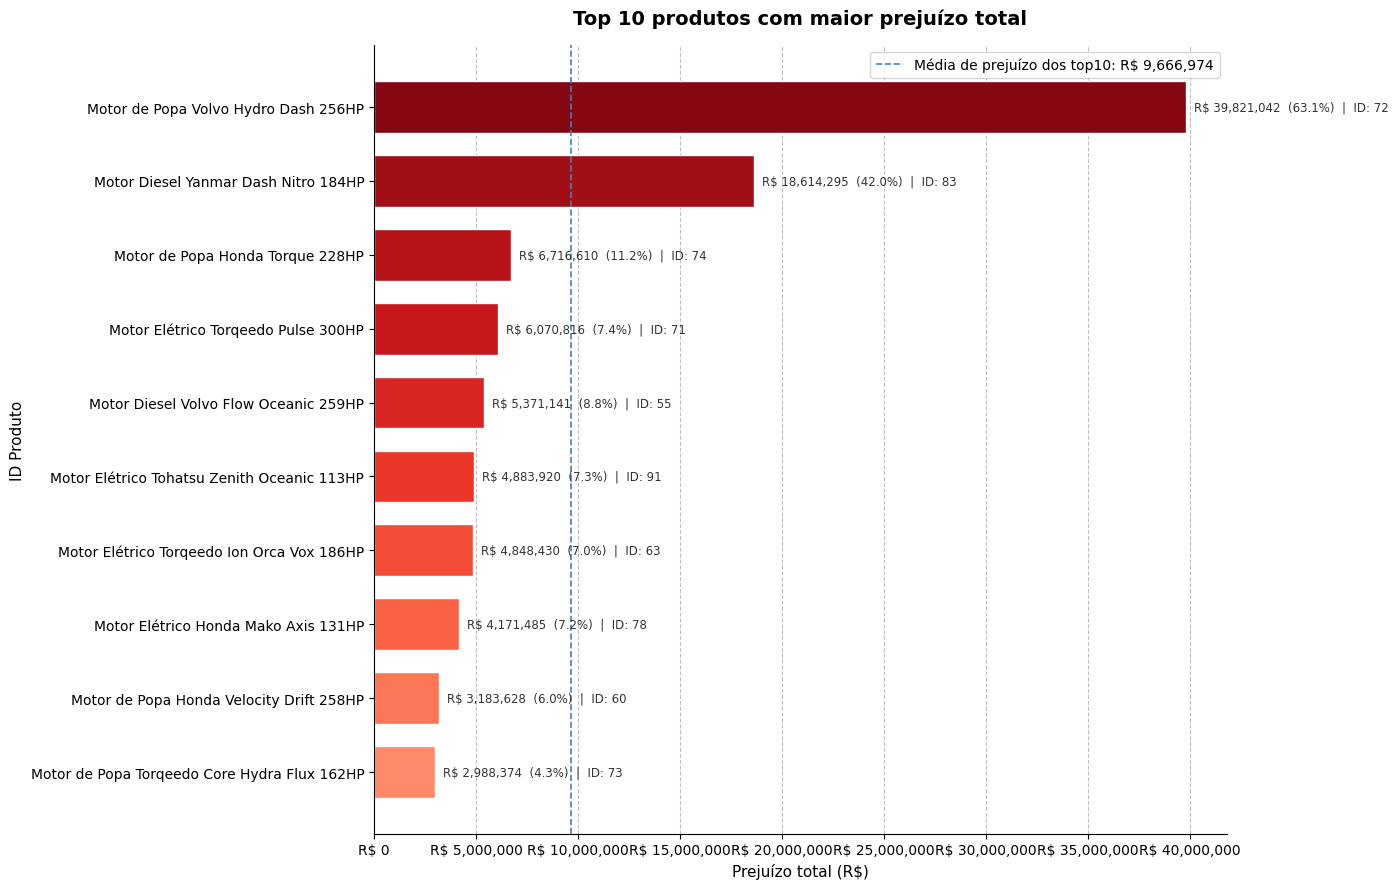

In [125]:
top10 = df_agg.nlargest(10, 'prejuizo_total')

fig, ax = plt.subplots(figsize=(14, 9))

# Gradiente de cores
colors = plt.cm.Reds([0.4 + 0.6 * i / len(top10) for i in range(len(top10))])[::-1]

bars = ax.barh(top10['name'].astype(str), top10['prejuizo_total'], color=colors, edgecolor='white', height=0.7)

# Valor + percentual + id no final de cada barra
for bar, valor, perc, id_prod in zip(bars, top10['prejuizo_total'], top10['percentual_perda'], top10['id_product']):
    ax.text(
        bar.get_width() + top10['prejuizo_total'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {valor:,.0f}  ({perc:.1f}%)  |  ID: {id_prod}",
        va='center', fontsize=8.5, color='#333333'
    )

# Linha de média
media = top10['prejuizo_total'].mean()
ax.axvline(media, color='steelblue', linestyle='--', linewidth=1.2, label=f'Média de prejuízo dos top10: R$ {media:,.0f}')

# Formatação dos eixos
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlabel('Prejuízo total (R$)', fontsize=11)
ax.set_ylabel('ID Produto', fontsize=11)
ax.set_title('Top 10 produtos com maior prejuízo total', fontsize=14, fontweight='bold', pad=15)

# Remove bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid suave
ax.xaxis.grid(True, linestyle='--', alpha=0.8)
ax.set_axisbelow(True)

ax.invert_yaxis()
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/reports/prejuizo_por_produto.png', dpi=150, bbox_inches='tight')
plt.show()

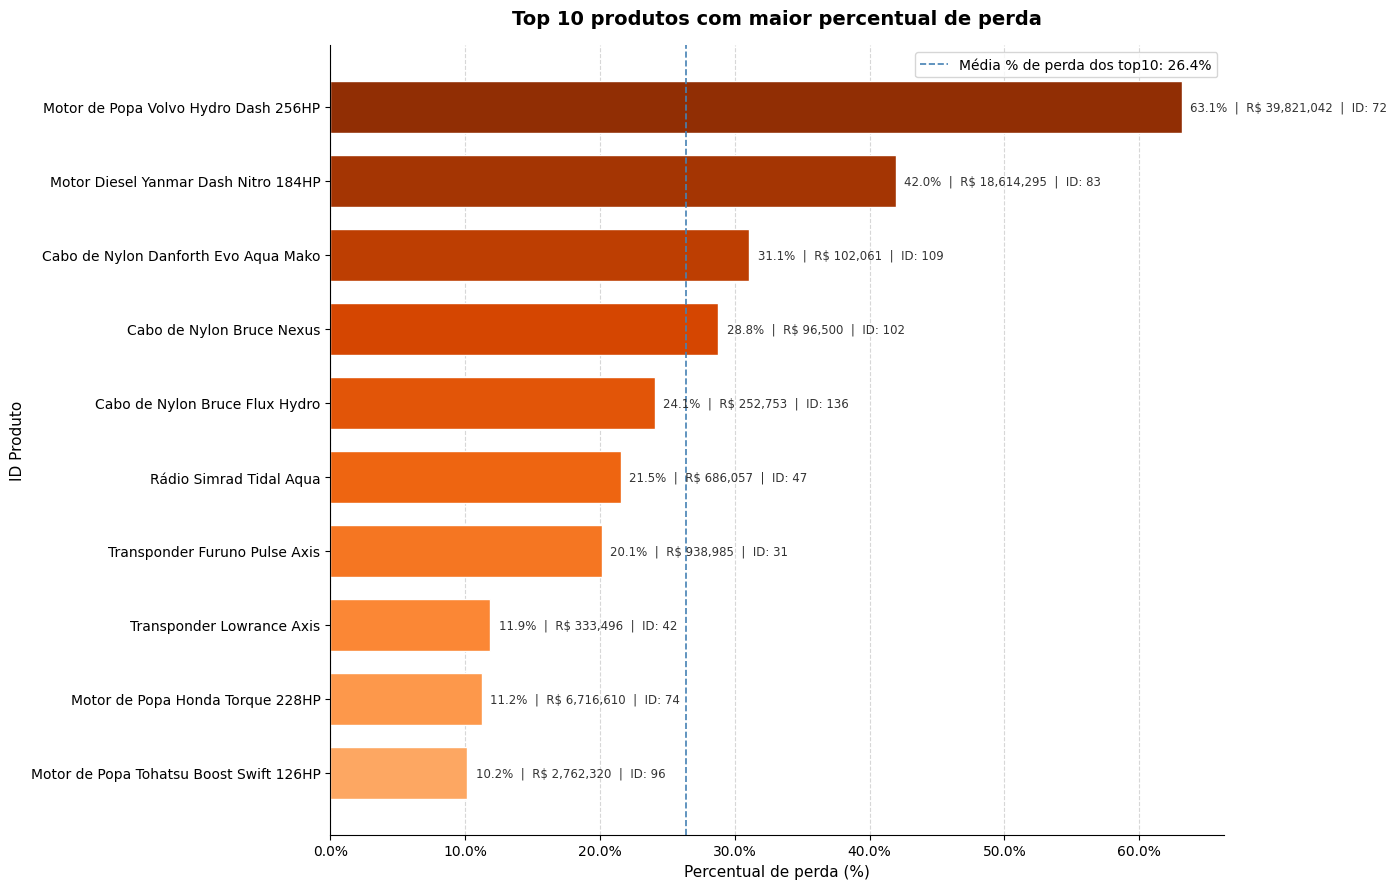

In [126]:
top10_perc = df_agg.nlargest(10, 'percentual_perda')

fig, ax = plt.subplots(figsize=(14, 9))

# Gradiente de cores
colors = plt.cm.Oranges([0.4 + 0.6 * i / len(top10_perc) for i in range(len(top10_perc))])[::-1]

bars = ax.barh(top10_perc['name'].astype(str), top10_perc['percentual_perda'], color=colors, edgecolor='white', height=0.7)

# Valor + percentual + id no final de cada barra
for bar, perc, prejuizo, id_prod in zip(bars, top10_perc['percentual_perda'], top10_perc['prejuizo_total'], top10_perc['id_product']):
    ax.text(
        bar.get_width() + top10_perc['percentual_perda'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{perc:.1f}%  |  R$ {prejuizo:,.0f}  |  ID: {id_prod}",
        va='center', fontsize=8.5, color='#333333'
    )

# Linha de média
media = top10_perc['percentual_perda'].mean()
ax.axvline(media, color='steelblue', linestyle='--', linewidth=1.2, label=f'Média % de perda dos top10: {media:.1f}%')

# Formatação dos eixos
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_xlabel('Percentual de perda (%)', fontsize=11)
ax.set_ylabel('ID Produto', fontsize=11)
ax.set_title('Top 10 produtos com maior percentual de perda', fontsize=14, fontweight='bold', pad=15)

# Remove bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid suave
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.invert_yaxis()
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/reports/percentual_perda_por_produto.png', dpi=150, bbox_inches='tight')
plt.show()